<a href="https://colab.research.google.com/github/tylerdurdenhere/db_and_analytics/blob/main/python_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install & Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# Upload & Load All Sheets
uploaded = files.upload()  # Upload when prompted

xl = pd.ExcelFile('dataset.xlsx')
print("Sheets found:", xl.sheet_names)

# Load all sheets
app_events  = pd.read_excel(xl, sheet_name='app_events')
complaints  = pd.read_excel(xl, sheet_name='complaints')
customers   = pd.read_excel(xl, sheet_name='customers')
data_dictionary = pd.read_excel(xl, sheet_name='data_dictionary')
deliveries  = pd.read_excel(xl, sheet_name='deliveries')
drivers     = pd.read_excel(xl, sheet_name='drivers')
hubs        = pd.read_excel(xl, sheet_name='hubs')
incidents   = pd.read_excel(xl, sheet_name='incidents')
orders      = pd.read_excel(xl, sheet_name='orders')
vehicles    = pd.read_excel(xl, sheet_name='vehicles')

print("\nAll sheets loaded.")
for name, df in [('app_events',app_events),('complaints',complaints),
                 ('customers',customers),('data_dictionary', data_dictionary),
                 ('deliveries',deliveries),('drivers',drivers),('hubs',hubs),
                 ('incidents',incidents),('orders',orders),('vehicles',vehicles)]:
    print(f"  {name:15s} → {df.shape[0]} rows, {df.shape[1]} cols")

Saving dataset.xlsx to dataset.xlsx
Sheets found: ['app_events', 'complaints', 'customers', 'data_dictionary', 'deliveries', 'drivers', 'hubs', 'incidents', 'orders', 'vehicles']

All sheets loaded.
  app_events      → 640 rows, 10 cols
  complaints      → 320 rows, 10 cols
  customers       → 650 rows, 9 cols
  data_dictionary → 9 rows, 3 cols
  deliveries      → 950 rows, 13 cols
  drivers         → 170 rows, 8 cols
  hubs            → 8 rows, 5 cols
  incidents       → 280 rows, 7 cols
  orders          → 1250 rows, 11 cols
  vehicles        → 120 rows, 8 cols


In [7]:
# Raw Data Quality Report
datasets = {
    'app_events': app_events, 'complaints': complaints,
    'customers': customers, 'data_dictionary': data_dictionary,
    'deliveries': deliveries, 'drivers': drivers,
    'hubs': hubs, 'incidents': incidents,
    'orders': orders, 'vehicles': vehicles
}

print("=" * 60)
print("MISSING VALUE REPORT")
print("=" * 60)
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"\n{name}:")
        for col, cnt in missing.items():
            pct = cnt / len(df) * 100
            print(f"  {col:40s} {cnt:4d} missing ({pct:.1f}%)")

print("\n" + "=" * 60)
print("ZONE INCONSISTENCY CHECK (before cleaning)")
print("=" * 60)
zone_cols = {
    'customers':  'home_zone',
    'orders':     'pickup_zone',
    'drivers':    'base_zone',
    'vehicles':   'assigned_zone',
    'app_events': 'zone_context'
}
for sheet, col in zone_cols.items():
    vals = datasets[sheet][col].dropna().unique()
    print(f"\n{sheet}.{col}:")
    print(f"  {sorted([str(v) for v in vals])}")

MISSING VALUE REPORT

app_events:
  order_id                                  144 missing (22.5%)

deliveries:
  delivery_completed_at                      19 missing (2.0%)

ZONE INCONSISTENCY CHECK (before cleaning)

customers.home_zone:
  ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']

orders.pickup_zone:
  ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']

drivers.base_zone:
  ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']

vehicles.assigned_zone:
  ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']

app_events.zone_context:
  ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']


In [8]:
# Standardise Zone Values
# Canonical zone mapping
zone_map = {
    'north': 'North', 'NORTH': 'North', 'North': 'North',
    'south': 'South', 'SOUTH': 'South', 'South': 'South',
    'east':  'East',  'EAST':  'East',  'East':  'East',
    'west':  'West',  'WEST':  'West',  'West':  'West',
    'central': 'Central', 'CENTRAL': 'Central', 'Central': 'Central', 'Ctr': 'Central',
    'airport': 'Airport', 'AIRPORT': 'Airport', 'Airport': 'Airport',
    'riverside': 'Riverside', 'RIVERSIDE': 'Riverside',
    'Riverside': 'Riverside', 'RiverSide': 'Riverside'
}

def standardise_zones(df, cols):
    df = df.copy()
    for col in cols:
        if col in df.columns:
            df[col] = df[col].map(lambda x: zone_map.get(str(x).strip(), x) if pd.notna(x) else x)
    return df

customers  = standardise_zones(customers,  ['home_zone'])
orders     = standardise_zones(orders,     ['pickup_zone', 'dropoff_zone'])
drivers    = standardise_zones(drivers,    ['base_zone'])
vehicles   = standardise_zones(vehicles,  ['assigned_zone'])
app_events = standardise_zones(app_events, ['zone_context'])

# Verify
print("Zone values after standardisation:")
for sheet, col in zone_cols.items():
    vals = sorted(datasets[sheet][col].dropna().unique()
                  if sheet != 'customers' else customers['home_zone'].dropna().unique())
    print(f"  {sheet}.{col}: {vals}")

print("\nZone standardisation complete.")

Zone values after standardisation:
  customers.home_zone: ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']
  orders.pickup_zone: ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']
  drivers.base_zone: ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']
  vehicles.assigned_zone: ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']
  app_events.zone_context: ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']

Zone standardisation complete.


In [9]:
# Handle Missing Values

# customers — fill loyalty_score with median, preferred_channel with mode
customers['loyalty_score'].fillna(customers['loyalty_score'].median(), inplace=True)
customers['preferred_channel'].fillna(customers['preferred_channel'].mode()[0], inplace=True)

# orders — fill booking_channel with 'Unknown'
orders['booking_channel'].fillna('Unknown', inplace=True)

# deliveries — fill rating with median; completed_at stays NaT (failed deliveries)
deliveries['customer_rating_post_delivery'].fillna(
    deliveries['customer_rating_post_delivery'].median(), inplace=True)

# drivers — fill training_score with median
drivers['training_score'].fillna(drivers['training_score'].median(), inplace=True)

# complaints — fill compensation_amount with 0 (no compensation issued)
complaints['compensation_amount'].fillna(0, inplace=True)

# incidents — fill resolved_hours with median
incidents['resolved_hours'].fillna(incidents['resolved_hours'].median(), inplace=True)

# vehicles — fill battery_health_pct with median
vehicles['battery_health_pct'].fillna(vehicles['battery_health_pct'].median(), inplace=True)

# app_events — order_id NaN is valid (session-only events), leave as-is

print("Missing value treatment summary:")
for name, df in datasets.items():
    remaining = df.isnull().sum().sum()
    print(f"  {name:15s} → {remaining} missing values remaining")

Missing value treatment summary:
  app_events      → 144 missing values remaining
  complaints      → 0 missing values remaining
  customers       → 0 missing values remaining
  data_dictionary → 0 missing values remaining
  deliveries      → 19 missing values remaining
  drivers         → 0 missing values remaining
  hubs            → 0 missing values remaining
  incidents       → 0 missing values remaining
  orders          → 0 missing values remaining
  vehicles        → 0 missing values remaining


In [10]:
# Feature Engineering

# --- Deliveries ---
# Delivery duration in hours
deliveries['dispatch_time'] = pd.to_datetime(deliveries['dispatch_time'])
deliveries['delivery_completed_at'] = pd.to_datetime(deliveries['delivery_completed_at'])
deliveries['delivery_duration_hrs'] = (
    deliveries['delivery_completed_at'] - deliveries['dispatch_time']
).dt.total_seconds() / 3600

# Binary delay flag
deliveries['is_delayed'] = deliveries['delivery_status'].apply(
    lambda x: 1 if x in ['Delayed', 'Failed'] else 0)

# High override flag (more than 1 manual override)
deliveries['high_override'] = (deliveries['manual_route_override_count'] > 1).astype(int)

# --- Orders ---
# Order value band
orders['value_band'] = pd.cut(orders['order_value'],
    bins=[0, 50, 100, 200, 500, 10000],
    labels=['<£50', '£50-100', '£100-200', '£200-500', '>£500'])

# Order hour of day
orders['order_hour'] = pd.to_datetime(orders['order_created_at']).dt.hour

# Order day of week
orders['order_dow'] = pd.to_datetime(orders['order_created_at']).dt.day_name()

# --- Customers ---
# Age band
customers['age_band'] = pd.cut(customers['age'],
    bins=[0, 25, 35, 50, 65, 120],
    labels=['18-25', '26-35', '36-50', '51-65', '65+'])

# --- Vehicles ---
# Low battery flag
vehicles['low_battery'] = (vehicles['battery_health_pct'] < 60).astype(int)

# --- Incidents ---
# Slow resolution flag (> 24 hours)
incidents['slow_resolution'] = (incidents['resolved_hours'] > 24).astype(int)

print("Feature engineering complete.")
print(f"\nNew features added:")
print(f"  deliveries : delivery_duration_hrs, is_delayed, high_override")
print(f"  orders     : value_band, order_hour, order_dow")
print(f"  customers  : age_band")
print(f"  vehicles   : low_battery")
print(f"  incidents  : slow_resolution")

Feature engineering complete.

New features added:
  deliveries : delivery_duration_hrs, is_delayed, high_override
  orders     : value_band, order_hour, order_dow
  customers  : age_band
  vehicles   : low_battery
  incidents  : slow_resolution


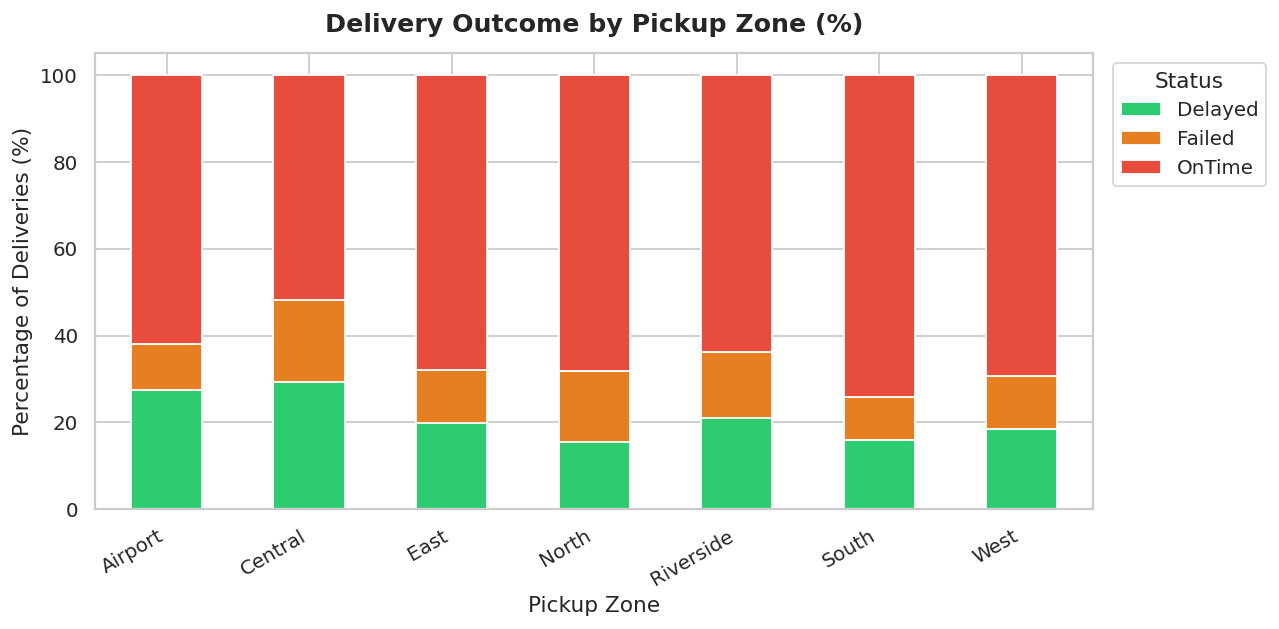

Insight: Identifies which zones have the highest failure and delay rates.


In [11]:
# Visualisation 1 — Delivery Status by Zone
# Join deliveries → orders to get pickup_zone
del_orders = deliveries.merge(
    orders[['order_id', 'pickup_zone']], on='order_id', how='left')

zone_status = del_orders.groupby(['pickup_zone', 'delivery_status']).size().unstack(fill_value=0)
zone_status_pct = zone_status.div(zone_status.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
zone_status_pct.plot(kind='bar', stacked=True, ax=ax,
    color=['#2ecc71', '#e67e22', '#e74c3c'], edgecolor='white')
ax.set_title('Delivery Outcome by Pickup Zone (%)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Pickup Zone', fontsize=12)
ax.set_ylabel('Percentage of Deliveries (%)', fontsize=12)
ax.legend(title='Status', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig('viz1_delivery_status_by_zone.png', bbox_inches='tight')
plt.show()
print("Insight: Identifies which zones have the highest failure and delay rates.")

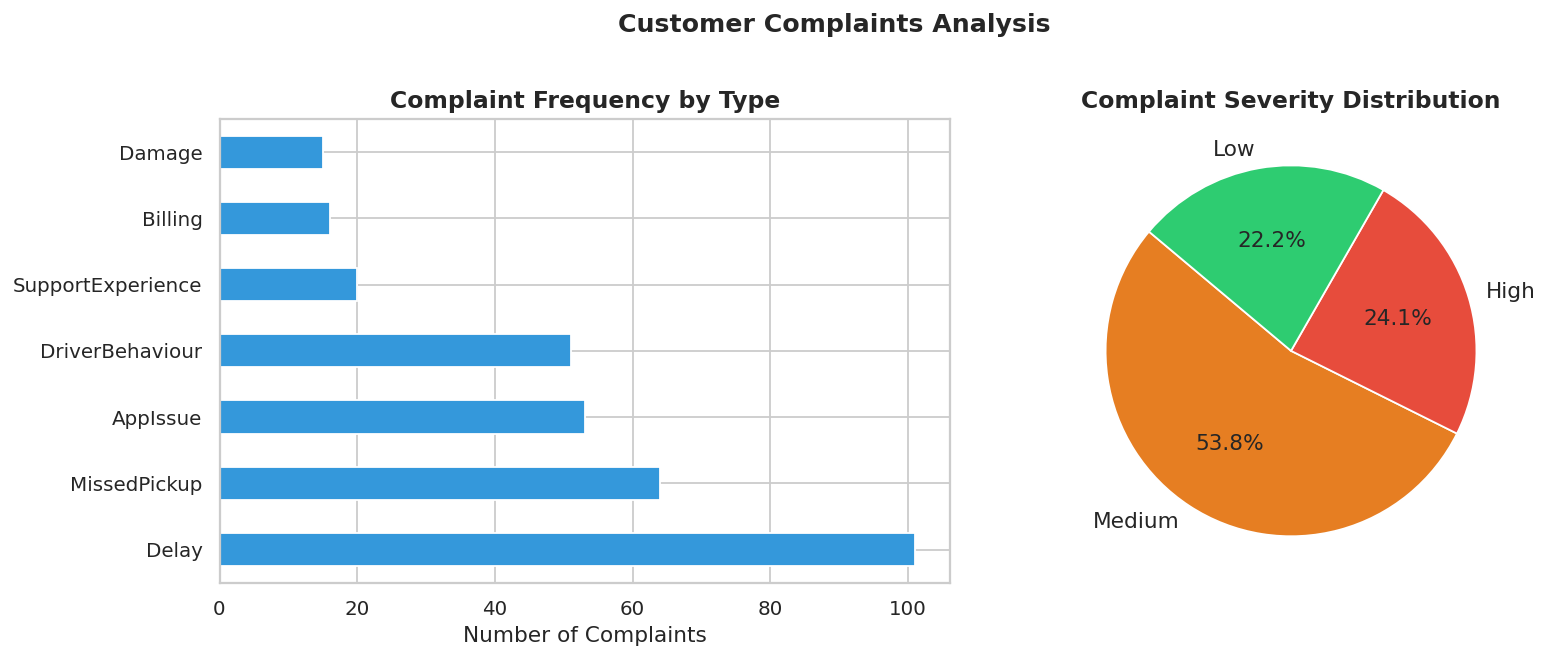

Insight: Delay and MissedPickup dominate complaints; High severity accounts for a significant share.


In [12]:
# Visualisation 2 — Complaint Types & Severity
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: complaint type frequency
comp_counts = complaints['complaint_type'].value_counts()
comp_counts.plot(kind='barh', ax=axes[0], color='#3498db', edgecolor='white')
axes[0].set_title('Complaint Frequency by Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Complaints')
axes[0].set_ylabel('')

# Right: severity distribution
sev_counts = complaints['severity'].value_counts()
colors = {'High': '#e74c3c', 'Medium': '#e67e22', 'Low': '#2ecc71'}
sev_colors = [colors[s] for s in sev_counts.index]
axes[1].pie(sev_counts, labels=sev_counts.index, autopct='%1.1f%%',
            colors=sev_colors, startangle=140, textprops={'fontsize': 12})
axes[1].set_title('Complaint Severity Distribution', fontsize=13, fontweight='bold')

plt.suptitle('Customer Complaints Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz2_complaints_analysis.png', bbox_inches='tight')
plt.show()
print("Insight: Delay and MissedPickup dominate complaints; High severity accounts for a significant share.")

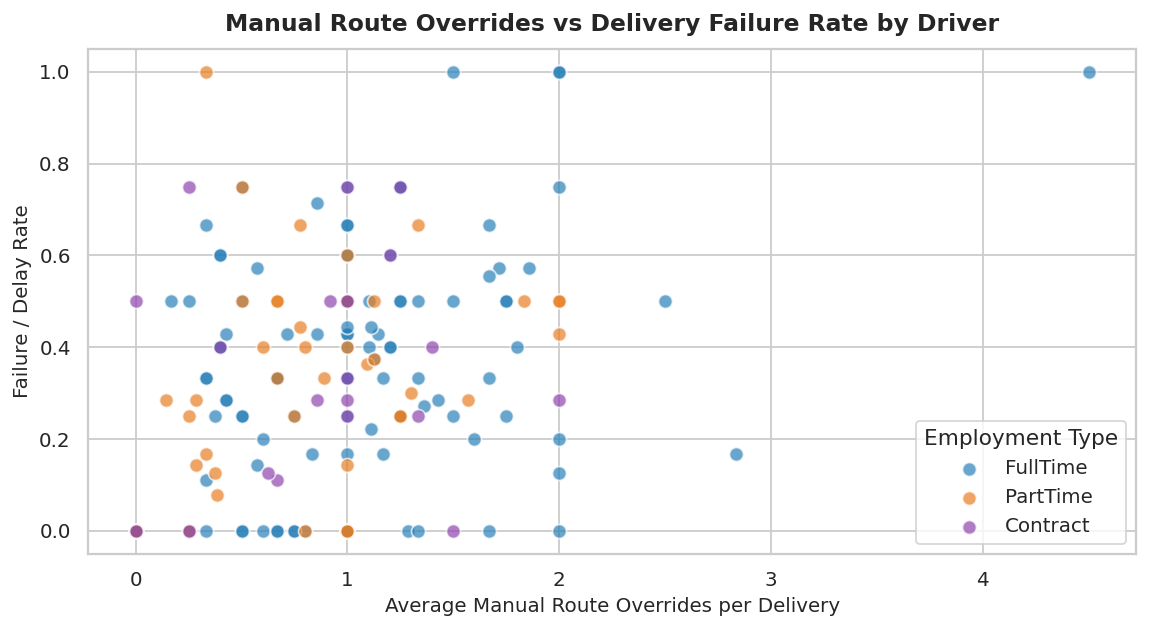

Insight: Higher override rates tend to correlate with higher failure/delay rates.


In [13]:
# Visualisation 3 — Driver Override Rate vs Delivery Outcome
driver_perf = deliveries.merge(drivers[['driver_id', 'driver_rating', 'employment_type']],
                                on='driver_id', how='left')
driver_summary = driver_perf.groupby('driver_id').agg(
    avg_overrides=('manual_route_override_count', 'mean'),
    failure_rate=('is_delayed', 'mean'),
    driver_rating=('driver_rating', 'first'),
    employment_type=('employment_type', 'first')
).reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
for etype, color in [('FullTime','#2980b9'), ('PartTime','#e67e22'), ('Contract','#8e44ad')]:
    sub = driver_summary[driver_summary['employment_type'] == etype]
    ax.scatter(sub['avg_overrides'], sub['failure_rate'],
               label=etype, color=color, alpha=0.7, s=60, edgecolors='white')

ax.set_title('Manual Route Overrides vs Delivery Failure Rate by Driver',
             fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Average Manual Route Overrides per Delivery', fontsize=11)
ax.set_ylabel('Failure / Delay Rate', fontsize=11)
ax.legend(title='Employment Type')
plt.tight_layout()
plt.savefig('viz3_override_vs_failure.png', bbox_inches='tight')
plt.show()
print("Insight: Higher override rates tend to correlate with higher failure/delay rates.")

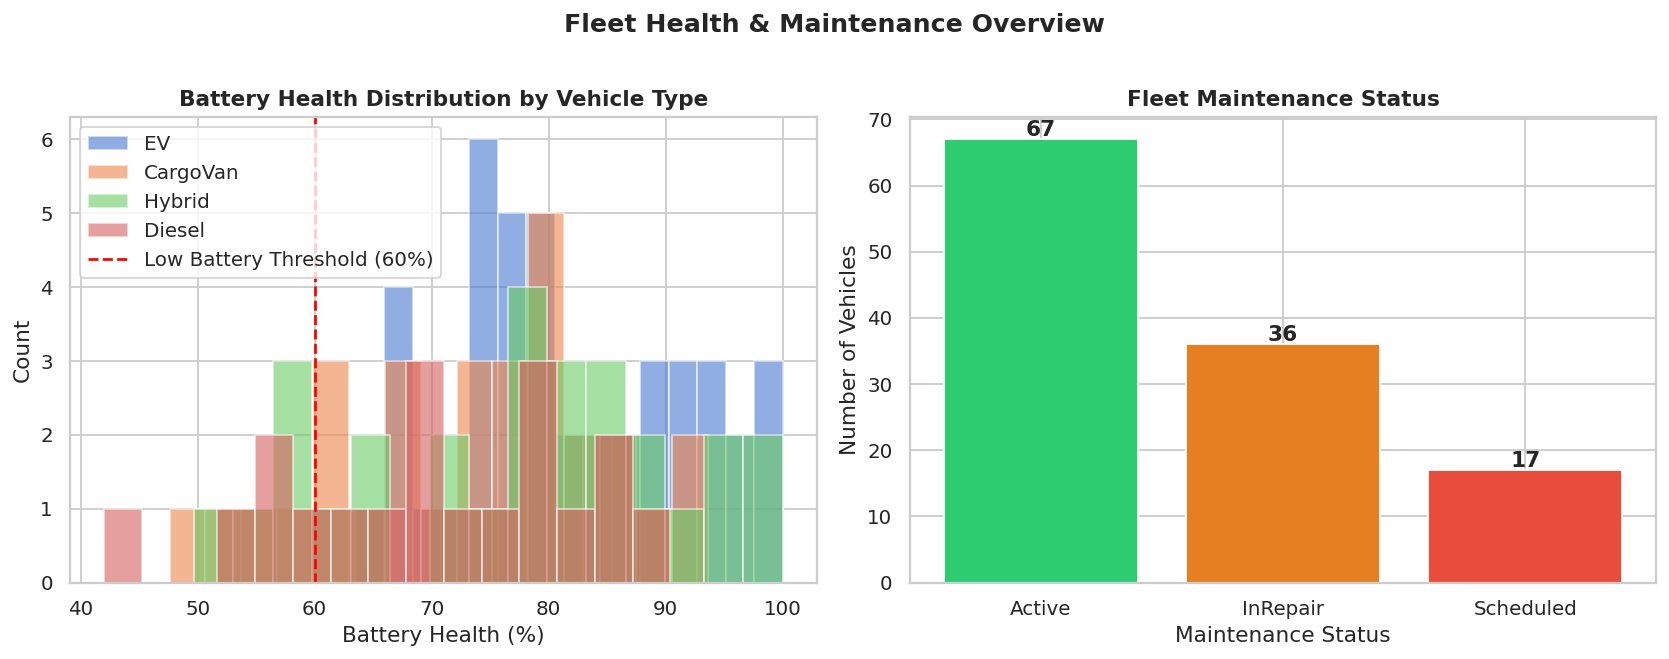

Insight: A proportion of EVs fall below 60% battery health — a maintenance risk for range reliability.


In [14]:
# Visualisation 4 — Vehicle Battery Health & Maintenance
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: battery health distribution by vehicle type
ev_vehicles = vehicles[vehicles['vehicle_type'] == 'EV']
for vtype in vehicles['vehicle_type'].unique():
    sub = vehicles[vehicles['vehicle_type'] == vtype]['battery_health_pct']
    axes[0].hist(sub, bins=15, alpha=0.6, label=vtype)
axes[0].axvline(60, color='red', linestyle='--', linewidth=1.5, label='Low Battery Threshold (60%)')
axes[0].set_title('Battery Health Distribution by Vehicle Type', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Battery Health (%)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Right: maintenance status breakdown
maint_counts = vehicles['maintenance_status'].value_counts()
colors = ['#2ecc71', '#e67e22', '#e74c3c']
axes[1].bar(maint_counts.index, maint_counts.values, color=colors, edgecolor='white')
axes[1].set_title('Fleet Maintenance Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Maintenance Status')
axes[1].set_ylabel('Number of Vehicles')
for i, v in enumerate(maint_counts.values):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.suptitle('Fleet Health & Maintenance Overview', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz4_fleet_health.png', bbox_inches='tight')
plt.show()
print("Insight: A proportion of EVs fall below 60% battery health — a maintenance risk for range reliability.")

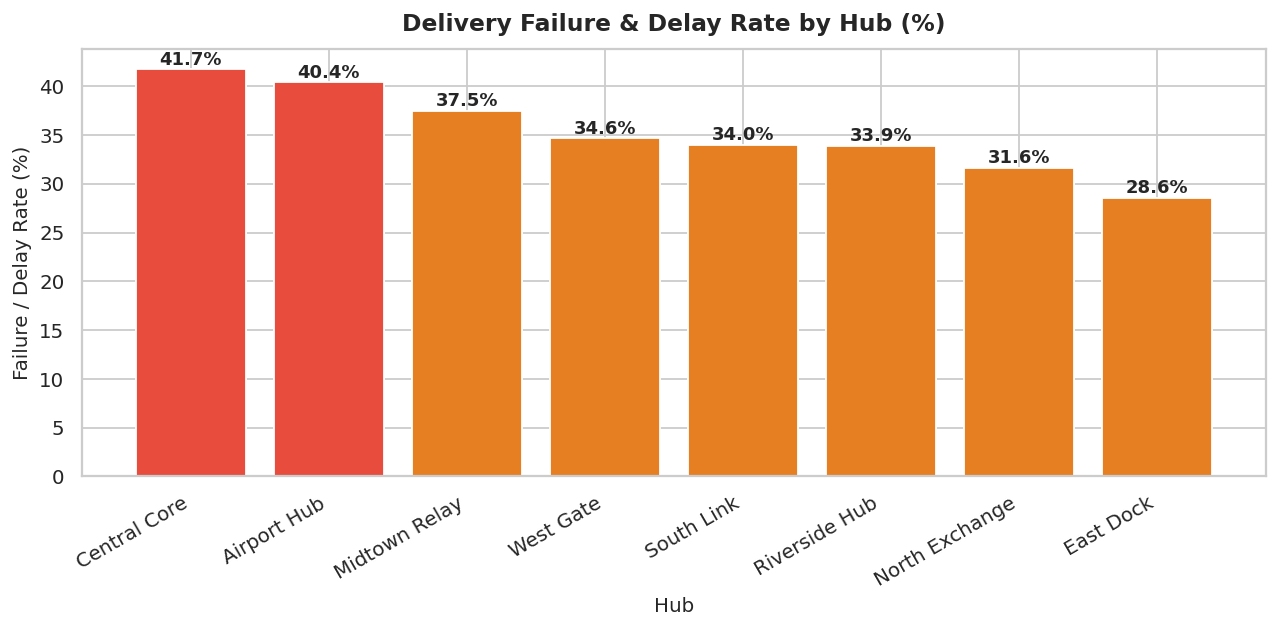

Insight: Identifies underperforming hubs that require operational intervention.


In [15]:
# Visualisation 5 — Hub Performance
hub_perf = deliveries.merge(hubs[['hub_id', 'hub_name', 'zone']], on='hub_id', how='left')
hub_summary = hub_perf.groupby(['hub_id', 'hub_name', 'zone']).agg(
    total_deliveries=('delivery_id', 'count'),
    failure_rate=('is_delayed', 'mean'),
    avg_rating=('customer_rating_post_delivery', 'mean'),
    avg_overrides=('manual_route_override_count', 'mean')
).reset_index().sort_values('failure_rate', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(hub_summary['hub_name'], hub_summary['failure_rate'] * 100,
              color=['#e74c3c' if r > 0.4 else '#e67e22' if r > 0.25 else '#2ecc71'
                     for r in hub_summary['failure_rate']],
              edgecolor='white')
ax.set_title('Delivery Failure & Delay Rate by Hub (%)', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Hub', fontsize=11)
ax.set_ylabel('Failure / Delay Rate (%)', fontsize=11)
ax.set_xticklabels(hub_summary['hub_name'], rotation=30, ha='right')
for bar, val in zip(bars, hub_summary['failure_rate'] * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('viz5_hub_performance.png', bbox_inches='tight')
plt.show()
print("Insight: Identifies underperforming hubs that require operational intervention.")

In [16]:
# Export Cleaned Datasets
cleaned = {
    'app_events_clean.csv':  app_events,
    'complaints_clean.csv':  complaints,
    'customers_clean.csv':   customers,
    'deliveries_clean.csv':  deliveries,
    'drivers_clean.csv':     drivers,
    'hubs_clean.csv':        hubs,
    'incidents_clean.csv':   incidents,
    'orders_clean.csv':      orders,
    'vehicles_clean.csv':    vehicles,
}

for filename, df in cleaned.items():
    df.to_csv(filename, index=False)
    print(f"Saved: {filename}  ({len(df)} rows)")

# Download all cleaned files
for filename in cleaned.keys():
    files.download(filename)

print("\nAll cleaned datasets exported and downloaded.")

Saved: app_events_clean.csv  (640 rows)
Saved: complaints_clean.csv  (320 rows)
Saved: customers_clean.csv  (650 rows)
Saved: deliveries_clean.csv  (950 rows)
Saved: drivers_clean.csv  (170 rows)
Saved: hubs_clean.csv  (8 rows)
Saved: incidents_clean.csv  (280 rows)
Saved: orders_clean.csv  (1250 rows)
Saved: vehicles_clean.csv  (120 rows)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All cleaned datasets exported and downloaded.
